In [3]:
import os
import librosa
import numpy as np

# --- Configuration Constants ---
# 22050 Hz is the standard sample rate for human voice analysis
SAMPLE_RATE = 22050 
# Force all audio clips to be exactly 3 seconds long for consistent matrix sizes
DURATION = 3 
# Extract 40 frequency bands (standard for speech recognition)
N_MFCC = 40 

def extract_features(file_path):
    """Loads an audio file, pads it if too short, and extracts its MFCC matrix."""
    # Load audio, automatically resampling and cutting it off at DURATION
    audio, sr = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
    
    # If the audio is shorter than 3 seconds, pad it with trailing zeros
    target_length = SAMPLE_RATE * DURATION
    if len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)))
        
    # Extract the Mel-Frequency Cepstral Coefficients
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC)
    return mfccs

def process_dataset(data_dir):
    """Loops through male and female folders to build the X (features) and y (labels) arrays."""
    X = []
    y = []
    
    # Define our binary classification labels to match the Kaggle folder names
    classes = {'male': 0, 'female': 1}
    
    for label_name, label_value in classes.items():
        folder_path = os.path.join(data_dir, label_name)
        
        # Skip if the folder doesn't exist
        if not os.path.exists(folder_path):
            print(f"Warning: Directory {folder_path} not found.")
            continue
            
        print(f"Processing '{label_name}' audio files...")
        
        # Iterate through every .wav file in the directory
        for filename in os.listdir(folder_path):
            if filename.endswith('.wav'):
                file_path = os.path.join(folder_path, filename)
                try:
                    features = extract_features(file_path)
                    X.append(features)
                    y.append(label_value)
                except Exception as e:
                    print(f"Error processing {filename}: {e}")
                    
    return np.array(X), np.array(y)

if __name__ == "__main__":
    # --- Define your directory paths ---
    # Update this path if your Kaggle dataset is stored somewhere else
    RAW_DATA_DIR = "../data/raw"
    PROCESSED_DATA_DIR = "../data/processed"
    
    # Ensure the output directory exists before saving
    os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
    
    print("Starting feature extraction pipeline...")
    X, y = process_dataset(RAW_DATA_DIR)
    
    if len(X) > 0:
        # Add a channel dimension so the PyTorch CNN treats it like a grayscale image
        X = X[..., np.newaxis] 
        
        print(f"\nFinal Features Shape (X): {X.shape}")
        print(f"Final Labels Shape (y): {y.shape}")
        
        # Save the arrays to disk so the train.py script can load them
        np.save(os.path.join(PROCESSED_DATA_DIR, 'X.npy'), X)
        np.save(os.path.join(PROCESSED_DATA_DIR, 'y.npy'), y)
        print("\nSuccess! Data converted and saved to data/processed/")
    else:
        print("\nNo audio files were processed. Please check that your data/raw/ directory contains the 'male' and 'female' folders.")

Starting feature extraction pipeline...
Processing 'male' audio files...
Processing 'female' audio files...

Final Features Shape (X): (16148, 40, 130, 1)
Final Labels Shape (y): (16148,)

Success! Data converted and saved to data/processed/


In [6]:
import os

In [9]:
import numpy as np
X=np.load(r"C:\Users\Pradum Gupta\OneDrive\Desktop\Coding\Gender Detection\data\processed\X.npy")

In [15]:
len(X[0])

40

## COde to visualize the MFCC

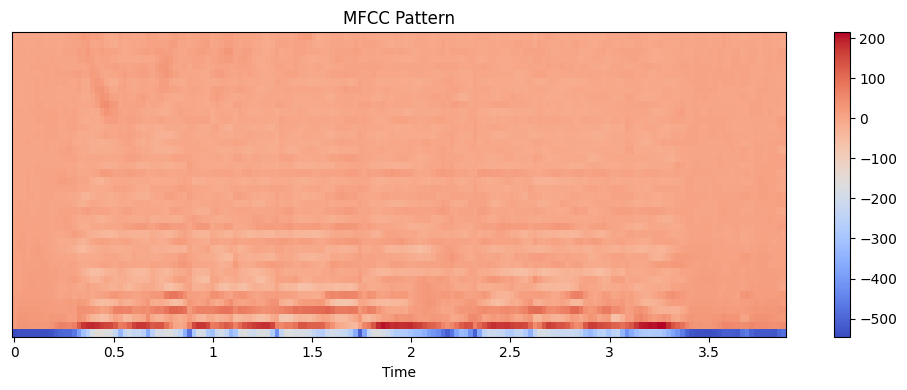

In [21]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# load audio file
audio, sr = librosa.load(r"C:\Users\Pradum Gupta\OneDrive\Desktop\Coding\Gender Detection\data\raw\male\arctic_a0002(11).wav", sr=22050)

# extract MFCC
mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

# plot MFCC
plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar()
plt.title("MFCC Pattern")
plt.tight_layout()
plt.show()

- Each audio is converted into 40 feature of MFCC with 130 time frame per audio

In [1]:
import numpy as np

# Load your processed training data
X = np.load(r"C:\Users\Pradum Gupta\OneDrive\Desktop\Coding\Gender Detection\data\processed\X.npy")

print(f"GLOBAL_MEAN = {X.mean()}")
print(f"GLOBAL_STD = {X.std()}")

GLOBAL_MEAN = -6.255115032196045
GLOBAL_STD = 59.61945724487305


In [1]:
import numpy as np

# Load your processed training data
X = np.load(r"C:\Users\Pradum Gupta\OneDrive\Desktop\Coding\Gender Detection\data\processed\X.npy")

print(f"GLOBAL_MEAN = {X.mean()}")
print(f"GLOBAL_STD = {X.std()}")

GLOBAL_MEAN = -52.98756790161133
GLOBAL_STD = 18.141178131103516
